# Prototype 2

**Dataset:** NJ Transit + Amtrak (NEC) Rail Performance — 2019 (6 months: Jan–Jun)

**Building on Prototype 1/1.5:** Expands to 6 months, introduces all three models (LR, RF, XGBoost), implements SMOTE within train-only pipelines, adds probability calibration, and performs threshold selection.

**Pipeline:** Load → Clean → Segment → Label → Features → Time Split → Train (with/without SMOTE) → Evaluate → Calibrate → Feature Importance → Ranked Segment Output

In [32]:
# Installs and Imports
!pip install -q imbalanced-learn xgboost openpyxl

import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE
from google.colab import drive
drive.mount('/content/drive')

EXPORT_DIR = 'prototype2_outputs'
os.makedirs(EXPORT_DIR, exist_ok=True)
print('All imports successful.')
print(f'Exports will be saved to: {EXPORT_DIR}/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful.
Exports will be saved to: prototype2_outputs/


## 1. Data Loading — 6 Months of 2019 (Jan–Jun)

In [33]:
# Load 6 months from Google Drive
BASE_PATH = '/content/drive/MyDrive/Datasets/2019/'
files = [f'{BASE_PATH}2019_{m:02d}.csv' for m in range(1, 7)]

missing = [f for f in files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError('Missing files:\n' + '\n'.join(missing))

dfs = []
for filepath in files:
    temp = pd.read_csv(filepath)
    temp['source_file'] = filepath.split('/')[-1]
    dfs.append(temp)
    print(f'Loaded {filepath.split("/")[-1]}: {temp.shape[0]:,} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(df['source_file'].value_counts().sort_index())

Loaded 2019_01.csv: 233,958 rows
Loaded 2019_02.csv: 216,055 rows
Loaded 2019_03.csv: 239,038 rows
Loaded 2019_04.csv: 238,693 rows
Loaded 2019_05.csv: 250,621 rows
Loaded 2019_06.csv: 238,759 rows

Combined: 1,417,124 rows x 14 columns
source_file
2019_01.csv    233958
2019_02.csv    216055
2019_03.csv    239038
2019_04.csv    238693
2019_05.csv    250621
2019_06.csv    238759
Name: count, dtype: int64


In [34]:
# Sanity checks
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False))
print('\nFirst 5 rows:')
display(df.head())


Columns: ['date', 'train_id', 'stop_sequence', 'from', 'from_id', 'to', 'to_id', 'scheduled_time', 'actual_time', 'delay_minutes', 'status', 'line', 'type', 'source_file']

Data types:
date               object
train_id           object
stop_sequence     float64
from               object
from_id           float64
to                 object
to_id             float64
scheduled_time     object
actual_time        object
delay_minutes     float64
status             object
line               object
type               object
source_file        object
dtype: object

Missing values:
stop_sequence     152032
scheduled_time    152032
delay_minutes     152032
to_id                395
from_id              395
train_id               0
to                     0
from                   0
date                   0
actual_time            0
status                 0
line                   0
type                   0
source_file            0
dtype: int64

First 5 rows:


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type,source_file
0,2019-01-01,.8905,NaN,New York Penn Station,105.0,New York Penn Station,105.0,NaN,2019-01-01 02:20:04,NaN,cancelled,Morristown Line,Amtrak,2019_01.csv
1,2019-01-01,.8905,NaN,New York Penn Station,105.0,Secaucus Upper Lvl,38187.0,NaN,2019-01-01 02:20:04,NaN,departed,Morristown Line,Amtrak,2019_01.csv
2,2019-01-01,A2228,NaN,Philadelphia,1.0,Philadelphia,1.0,NaN,2019-01-01 21:40:06,NaN,departed,ACELA EXPRESS,Amtrak,2019_01.csv
3,2019-01-01,A2228,NaN,Philadelphia,1.0,Metropark,83.0,NaN,2019-01-01 22:24:07,NaN,departed,ACELA EXPRESS,Amtrak,2019_01.csv
4,2019-01-01,A2228,NaN,Metropark,83.0,Newark Penn Station,107.0,NaN,2019-01-01 22:38:19,NaN,departed,ACELA EXPRESS,Amtrak,2019_01.csv


## 2. Data Cleaning

In [35]:
# Cleaning
df.columns = [c.strip() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['delay_minutes'] = pd.to_numeric(df['delay_minutes'], errors='coerce')
df['stop_sequence'] = pd.to_numeric(df['stop_sequence'], errors='coerce')
for col in ['scheduled_time', 'actual_time']:
    if col in df.columns: df[col] = pd.to_datetime(df[col], errors='coerce')

before = len(df)
df = df.dropna(subset=['date', 'delay_minutes']).copy()
print(f'Before: {before:,} | After: {len(df):,} | Dropped: {before-len(df):,} ({(before-len(df))/before*100:.1f}%)')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Before: 1,417,124 | After: 1,265,092 | Dropped: 152,032 (10.7%)
Date range: 2019-01-01 to 2019-06-30


count    1.265092e+06
mean     4.024956e+00
std      5.950406e+00
min      0.000000e+00
50%      2.400000e+00
75%      5.083333e+00
90%      8.650000e+00
95%      1.300000e+01
99%      2.800000e+01
max      3.260000e+02
Name: delay_minutes, dtype: float64


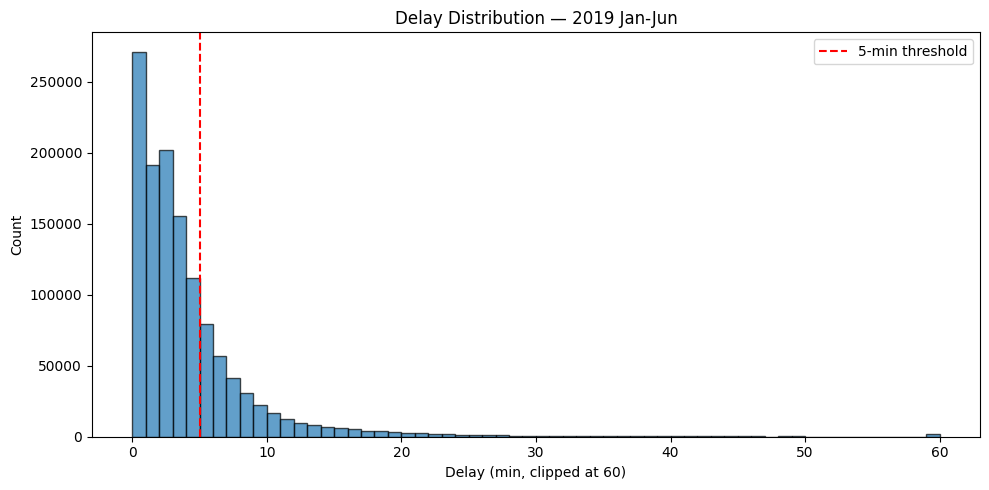

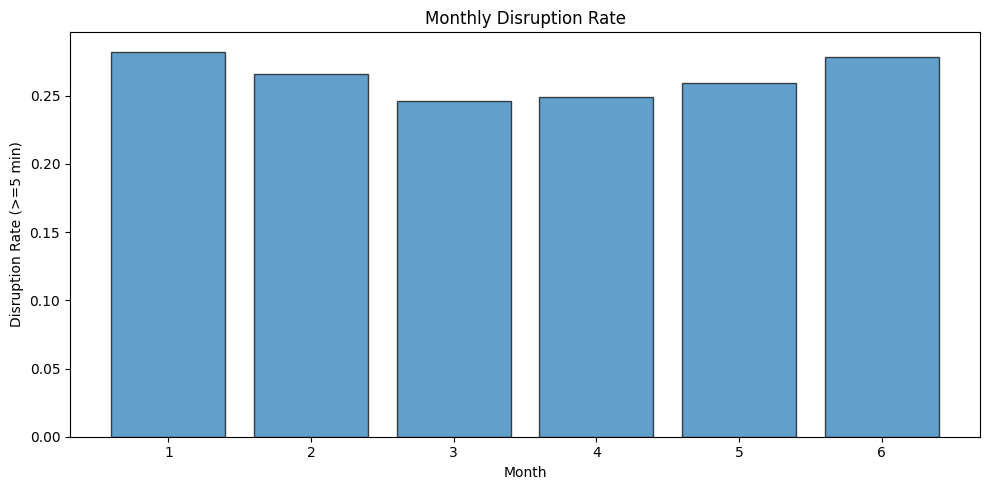

Saved: fig_delay_histogram.png + fig_monthly_disruption_rate.png


In [36]:
# Delay distribution — individual plots
print(df['delay_minutes'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# Plot 1: Delay histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['delay_minutes'].clip(upper=60), bins=60, edgecolor='black', alpha=0.7)
ax.set_xlabel('Delay (min, clipped at 60)'); ax.set_ylabel('Count')
ax.set_title('Delay Distribution — 2019 Jan-Jun')
ax.axvline(x=5, color='red', linestyle='--', label='5-min threshold'); ax.legend()
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_delay_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Monthly disruption rate
fig, ax = plt.subplots(figsize=(10, 5))
monthly = df.groupby(df['date'].dt.month).apply(lambda g: (g['delay_minutes']>=5).mean())
ax.bar(monthly.index, monthly.values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Month'); ax.set_ylabel('Disruption Rate (>=5 min)')
ax.set_title('Monthly Disruption Rate'); ax.set_xticks(range(1,7))
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_monthly_disruption_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_delay_histogram.png + fig_monthly_disruption_rate.png')


## 3. Segment Construction and Labelling

In [37]:
# Segments
if 'from_id' in df.columns and 'to_id' in df.columns:
    df['segment_id'] = df['from_id'].astype(str) + '->' + df['to_id'].astype(str)
else:
    df['segment_id'] = df['from'].astype(str) + '->' + df['to'].astype(str)

print(f'Unique segments: {df["segment_id"].nunique()}')
print(df['segment_id'].value_counts().head(10))
df['segment_id'].value_counts().reset_index().to_excel(f'{EXPORT_DIR}/table_segment_counts.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_segment_counts.xlsx')

Unique segments: 561
segment_id
105.0->105.0      22492
105.0->38187.0    18628
38187.0->105.0    18528
63.0->63.0        17139
107.0->38187.0    13323
38187.0->107.0    12838
37953.0->107.0    11675
107.0->37953.0    11611
38174.0->63.0     11161
63.0->38174.0     11124
Name: count, dtype: int64
Saved: prototype2_outputs/table_segment_counts.xlsx


In [38]:
# Binary labels
THRESHOLD_MIN = 5
df['disruption'] = (df['delay_minutes'] >= THRESHOLD_MIN).astype(int)
print(df['disruption'].value_counts())
print(f'Positive rate: {df["disruption"].mean():.4f} ({df["disruption"].mean()*100:.1f}%)')
print(f'Imbalance ratio: {(df["disruption"]==0).sum()/(df["disruption"]==1).sum():.1f}:1')

ld = df['disruption'].value_counts().reset_index()
ld.columns = ['class','count']; ld['label'] = ld['class'].map({0:'No Disruption',1:'Disruption'})
ld.to_excel(f'{EXPORT_DIR}/table_label_distribution.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_label_distribution.xlsx')
display(ld)


disruption
0    931795
1    333297
Name: count, dtype: int64
Positive rate: 0.2635 (26.3%)
Imbalance ratio: 2.8:1
Saved: prototype2_outputs/table_label_distribution.xlsx


,class,count,label
0,0,931795,No Disruption
1,1,333297,Disruption


## 4. Feature Engineering

In [39]:
# Features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['sched_hour'] = df['scheduled_time'].dt.hour if 'scheduled_time' in df.columns else 0
df['stop_sequence'] = df['stop_sequence'].fillna(0)
df['sched_hour'] = df['sched_hour'].fillna(0)
print('Features created: day_of_week, month, is_weekend, sched_hour, stop_sequence')

Features created: day_of_week, month, is_weekend, sched_hour, stop_sequence


In [40]:
# Feature matrix
feat_num = ['day_of_week','month','sched_hour','stop_sequence','is_weekend']
feat_cat = [c for c in ['line','type'] if c in df.columns]
X = pd.get_dummies(df[feat_num + feat_cat].copy(), columns=feat_cat, drop_first=True)
y = df['disruption'].copy()
print(f'Feature matrix: {X.shape}')
for i, col in enumerate(X.columns): print(f'  {i+1}. {col}')
display(X.head())


Feature matrix: (1265092, 15)
  1. day_of_week
  2. month
  3. sched_hour
  4. stop_sequence
  5. is_weekend
  6. line_Bergen Co. Line 
  7. line_Gladstone Branch
  8. line_Main Line
  9. line_Montclair-Boonton
  10. line_Morristown Line
  11. line_No Jersey Coast
  12. line_Northeast Corrdr
  13. line_Pascack Valley
  14. line_Princeton Shuttle
  15. line_Raritan Valley


,day_of_week,month,sched_hour,stop_sequence,is_weekend,line_Bergen Co. Line,line_Gladstone Branch,line_Main Line,line_Montclair-Boonton,line_Morristown Line,line_No Jersey Coast,line_Northeast Corrdr,line_Pascack Valley,line_Princeton Shuttle,line_Raritan Valley
6,1,1,23,1.0,0,False,False,False,True,False,False,False,False,False,False
7,1,1,23,2.0,0,False,False,False,True,False,False,False,False,False,False
8,1,1,23,3.0,0,False,False,False,True,False,False,False,False,False,False
9,1,1,23,4.0,0,False,False,False,True,False,False,False,False,False,False
10,1,1,23,5.0,0,False,False,False,True,False,False,False,False,False,False


## 5. Time-Based Split (Train 70% / Val 15% / Test 15%)

In [41]:
# Chronological split
df_sorted = df.sort_values('date').copy()
X_sorted = X.loc[df_sorted.index].copy()
y_sorted = y.loc[df_sorted.index].copy()
n = len(df_sorted)
train_end = int(n * 0.70); val_end = int(n * 0.85)

X_train, y_train = X_sorted.iloc[:train_end], y_sorted.iloc[:train_end]
X_val, y_val = X_sorted.iloc[train_end:val_end], y_sorted.iloc[train_end:val_end]
X_test, y_test = X_sorted.iloc[val_end:], y_sorted.iloc[val_end:]
dates_sorted = df_sorted['date']

print(' Time-Based Split ')
print(f'Train: {dates_sorted.iloc[0].date()} to {dates_sorted.iloc[train_end-1].date()} | {len(X_train):,} rows | pos: {y_train.mean():.4f}')
print(f'Val:   {dates_sorted.iloc[train_end].date()} to {dates_sorted.iloc[val_end-1].date()} | {len(X_val):,} rows | pos: {y_val.mean():.4f}')
print(f'Test:  {dates_sorted.iloc[val_end].date()} to {dates_sorted.iloc[-1].date()} | {len(X_test):,} rows | pos: {y_test.mean():.4f}')
assert dates_sorted.iloc[train_end-1] <= dates_sorted.iloc[train_end]
assert dates_sorted.iloc[val_end-1] <= dates_sorted.iloc[val_end]
print('No temporal leakage.')

split_info = pd.DataFrame([
    {'Set':'Train','Start':str(dates_sorted.iloc[0].date()),'End':str(dates_sorted.iloc[train_end-1].date()),'Rows':len(X_train),'Pos_Rate':round(y_train.mean(),4)},
    {'Set':'Val','Start':str(dates_sorted.iloc[train_end].date()),'End':str(dates_sorted.iloc[val_end-1].date()),'Rows':len(X_val),'Pos_Rate':round(y_val.mean(),4)},
    {'Set':'Test','Start':str(dates_sorted.iloc[val_end].date()),'End':str(dates_sorted.iloc[-1].date()),'Rows':len(X_test),'Pos_Rate':round(y_test.mean(),4)},
])
display(split_info)
split_info.to_excel(f'{EXPORT_DIR}/table_split_info.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_split_info.xlsx')


 Time-Based Split 
Train: 2019-01-01 to 2019-05-08 | 885,564 rows | pos: 0.2601
Val:   2019-05-08 to 2019-06-04 | 189,764 rows | pos: 0.2616
Test:  2019-06-04 to 2019-06-30 | 189,764 rows | pos: 0.2810
No temporal leakage.


,Set,Start,End,Rows,Pos_Rate
0,Train,2019-01-01,2019-05-08,885564,0.2601
1,Val,2019-05-08,2019-06-04,189764,0.2616
2,Test,2019-06-04,2019-06-30,189764,0.2810


Saved: prototype2_outputs/table_split_info.xlsx


## 6. Model Training — Class Weighting Only

In [42]:
# Train with class weighting
neg = (y_train==0).sum(); pos = (y_train==1).sum(); spw = neg/pos
print(f'Train — Neg: {neg:,}  Pos: {pos:,}  scale_pos_weight: {spw:.2f}')

def evaluate_model(model, X_e, y_e):
    yp = model.predict(X_e); ypr = model.predict_proba(X_e)[:,1]
    return {'y_pred':yp,'y_prob':ypr,'pr_auc':average_precision_score(y_e,ypr),
            'precision':precision_score(y_e,yp,zero_division=0),'recall':recall_score(y_e,yp,zero_division=0),
            'f1':f1_score(y_e,yp,zero_division=0),'accuracy':accuracy_score(y_e,yp),'cm':confusion_matrix(y_e,yp)}

models_w = {
    'LR + class weight': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF + class weight': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB + class weight': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=spw, eval_metric='aucpr', random_state=42, use_label_encoder=False)
}
results_w = {}
for name, mdl in models_w.items():
    print(f'\nTraining: {name}...')
    if 'XGB' in name: mdl.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else: mdl.fit(X_train, y_train)
    r = evaluate_model(mdl, X_test, y_test); r['model'] = mdl; results_w[name] = r
    print(f'  PR-AUC:{r["pr_auc"]:.4f} | Prec:{r["precision"]:.4f} | Rec:{r["recall"]:.4f} | F1:{r["f1"]:.4f} | Acc:{r["accuracy"]:.4f}')
    print(f'  CM:\n{r["cm"]}')
print('\nDone — class-weighted models.')

Train — Neg: 655,247  Pos: 230,317  scale_pos_weight: 2.84

Training: LR + class weight...
  PR-AUC:0.3294 | Prec:0.3455 | Rec:0.3461 | F1:0.3458 | Acc:0.6320
  CM:
[[101478  34956]
 [ 34875  18455]]

Training: RF + class weight...
  PR-AUC:0.3982 | Prec:0.3987 | Rec:0.4658 | F1:0.4296 | Acc:0.6524
  CM:
[[98966 37468]
 [28488 24842]]

Training: XGB + class weight...
  PR-AUC:0.4357 | Prec:0.3959 | Rec:0.6419 | F1:0.4897 | Acc:0.6241
  CM:
[[84206 52228]
 [19100 34230]]

Done — class-weighted models.


## 7. Model Training — Class Weighting + SMOTE

In [43]:
# SMOTE on training data only
print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {dict(pd.Series(y_tr_sm).value_counts())}')
print(f'Size: {len(X_train):,} -> {len(X_tr_sm):,}')
print('Val/Test UNCHANGED.')

Before SMOTE: {0: np.int64(655247), 1: np.int64(230317)}
After SMOTE: {0: np.int64(655247), 1: np.int64(327623)}
Size: 885,564 -> 982,870
Val/Test UNCHANGED.


In [44]:
# Train on SMOTE data
models_s = {
    'LR + CW + SMOTE': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF + CW + SMOTE': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB + CW + SMOTE': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=spw, eval_metric='aucpr', random_state=42, use_label_encoder=False)
}
results_s = {}
for name, mdl in models_s.items():
    print(f'\nTraining: {name}...')
    if 'XGB' in name: mdl.fit(X_tr_sm, y_tr_sm, eval_set=[(X_val, y_val)], verbose=False)
    else: mdl.fit(X_tr_sm, y_tr_sm)
    r = evaluate_model(mdl, X_test, y_test); r['model'] = mdl; results_s[name] = r
    print(f'  PR-AUC:{r["pr_auc"]:.4f} | Prec:{r["precision"]:.4f} | Rec:{r["recall"]:.4f} | F1:{r["f1"]:.4f} | Acc:{r["accuracy"]:.4f}')
    print(f'  CM:\n{r["cm"]}')
print('\nDone — SMOTE models.')


Training: LR + CW + SMOTE...
  PR-AUC:0.3277 | Prec:0.3432 | Rec:0.2804 | F1:0.3086 | Acc:0.6470
  CM:
[[107817  28617]
 [ 38378  14952]]

Training: RF + CW + SMOTE...
  PR-AUC:0.3963 | Prec:0.3999 | Rec:0.4502 | F1:0.4235 | Acc:0.6556
  CM:
[[100401  36033]
 [ 29323  24007]]

Training: XGB + CW + SMOTE...
  PR-AUC:0.4309 | Prec:0.3688 | Rec:0.7492 | F1:0.4943 | Acc:0.5692
  CM:
[[68050 68384]
 [13374 39956]]

Done — SMOTE models.


## 8. Comparative Results Table

In [45]:
# Comparison
all_r = {**results_w, **results_s}
rows = [{'Model':n,'PR-AUC':round(r['pr_auc'],4),'Precision':round(r['precision'],4),'Recall':round(r['recall'],4),'F1':round(r['f1'],4),'Accuracy':round(r['accuracy'],4)} for n,r in all_r.items()]
comp_df = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('PROTOTYPE 2 — MODEL COMPARISON (Test Set, >= 5 min)')
print(comp_df.to_string(index=False))
comp_df.to_excel(f'{EXPORT_DIR}/table_model_comparison.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_model_comparison.xlsx')
display(comp_df)


PROTOTYPE 2 — MODEL COMPARISON (Test Set, >= 5 min)
             Model  PR-AUC  Precision  Recall     F1  Accuracy
XGB + class weight  0.4357     0.3959  0.6419 0.4897    0.6241
  XGB + CW + SMOTE  0.4309     0.3688  0.7492 0.4943    0.5692
 RF + class weight  0.3982     0.3987  0.4658 0.4296    0.6524
   RF + CW + SMOTE  0.3963     0.3999  0.4502 0.4235    0.6556
 LR + class weight  0.3294     0.3455  0.3461 0.3458    0.6320
   LR + CW + SMOTE  0.3277     0.3432  0.2804 0.3086    0.6470
Saved: prototype2_outputs/table_model_comparison.xlsx


,Model,PR-AUC,Precision,Recall,F1,Accuracy
0,XGB + class weight,0.4357,0.3959,0.6419,0.4897,0.6241
1,XGB + CW + SMOTE,0.4309,0.3688,0.7492,0.4943,0.5692
2,RF + class weight,0.3982,0.3987,0.4658,0.4296,0.6524
3,RF + CW + SMOTE,0.3963,0.3999,0.4502,0.4235,0.6556
4,LR + class weight,0.3294,0.3455,0.3461,0.3458,0.6320
5,LR + CW + SMOTE,0.3277,0.3432,0.2804,0.3086,0.6470


## 8b. Disruption Threshold Sensitivity — 5 min vs 10 min

In [46]:
# Threshold sensitivity — relabel at 10 minutes

# Compare the best model (XGB + CW) at 5-min vs 10-min threshold
# Uses the same features and time-based split.

THRESHOLD_10 = 10

# Create 10-min labels on the sorted dataframe
df_sorted['disruption_10'] = (df_sorted['delay_minutes'] >= THRESHOLD_10).astype(int)

y_train_10 = df_sorted['disruption_10'].iloc[:train_end]
y_val_10 = df_sorted['disruption_10'].iloc[train_end:val_end]
y_test_10 = df_sorted['disruption_10'].iloc[val_end:]

print(' Disruption Threshold Comparison ')
print(f'\n5-minute threshold:')
print(f'  Train pos rate: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)')
print(f'  Test pos rate:  {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)')
print(f'  Imbalance:      {(y_train==0).sum()/(y_train==1).sum():.1f}:1')

print(f'\n10-minute threshold:')
print(f'  Train pos rate: {y_train_10.mean():.4f} ({y_train_10.mean()*100:.1f}%)')
print(f'  Test pos rate:  {y_test_10.mean():.4f} ({y_test_10.mean()*100:.1f}%)')
print(f'  Imbalance:      {(y_train_10==0).sum()/(y_train_10==1).sum():.1f}:1')


 Disruption Threshold Comparison 

5-minute threshold:
  Train pos rate: 0.2601 (26.0%)
  Test pos rate:  0.2810 (28.1%)
  Imbalance:      2.8:1

10-minute threshold:
  Train pos rate: 0.0785 (7.9%)
  Test pos rate:  0.0951 (9.5%)
  Imbalance:      11.7:1


In [47]:
# Train XGB + CW at 10-minute threshold


neg_10 = (y_train_10 == 0).sum()
pos_10 = (y_train_10 == 1).sum()
spw_10 = neg_10 / pos_10
print(f'10-min threshold — Neg: {neg_10:,}  Pos: {pos_10:,}  scale_pos_weight: {spw_10:.2f}')

xgb_10 = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    scale_pos_weight=spw_10, eval_metric='aucpr',
    random_state=42, use_label_encoder=False
)
xgb_10.fit(X_train, y_train_10, eval_set=[(X_val, y_val_10)], verbose=False)

r_10 = evaluate_model(xgb_10, X_test, y_test_10)
print(f'\nXGB + CW @ 10-min threshold (test set):')
print(f'  PR-AUC: {r_10["pr_auc"]:.4f} | Prec: {r_10["precision"]:.4f} | Rec: {r_10["recall"]:.4f} | F1: {r_10["f1"]:.4f}')
print(f'  CM:\n{r_10["cm"]}')

print(f'\nClassification Report @ 10-min:')
print(classification_report(y_test_10, r_10['y_pred'],
      target_names=['No Disruption','Disruption'], digits=4))


10-min threshold — Neg: 816,023  Pos: 69,541  scale_pos_weight: 11.73

XGB + CW @ 10-min threshold (test set):
  PR-AUC: 0.2011 | Prec: 0.1646 | Rec: 0.5441 | F1: 0.2528
  CM:
[[121899  49819]
 [  8227   9819]]

Classification Report @ 10-min:
               precision    recall  f1-score   support

No Disruption     0.9368    0.7099    0.8077    171718
   Disruption     0.1646    0.5441    0.2528     18046

     accuracy                         0.6941    189764
    macro avg     0.5507    0.6270    0.5302    189764
 weighted avg     0.8633    0.6941    0.7549    189764



THRESHOLD COMPARISON — XGB + Class Weight (Test Set)


,Threshold,Pos_Rate_Train,Pos_Rate_Test,Imbalance,PR-AUC,Precision,Recall,F1
0,>= 5 min,26.0%,28.1%,2.8:1,0.4357,0.3959,0.6419,0.4897
1,>= 10 min,7.9%,9.5%,11.7:1,0.2011,0.1646,0.5441,0.2528


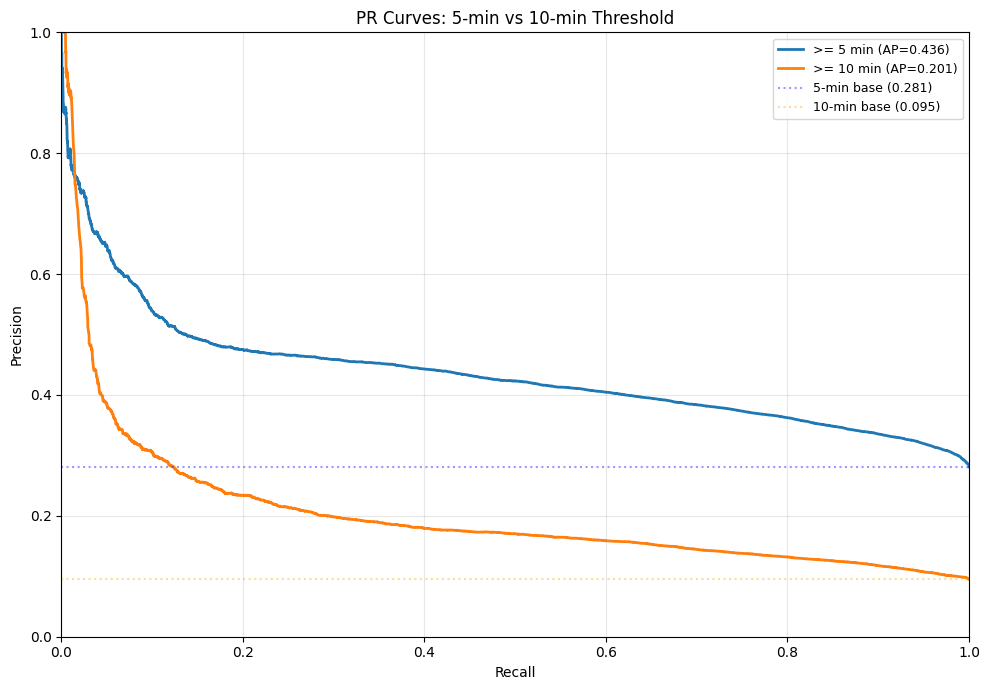

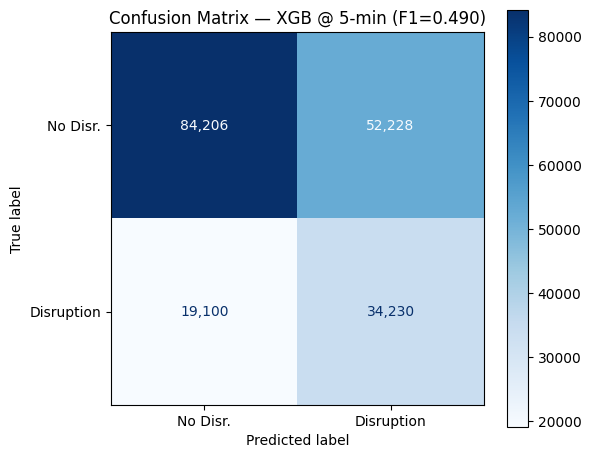

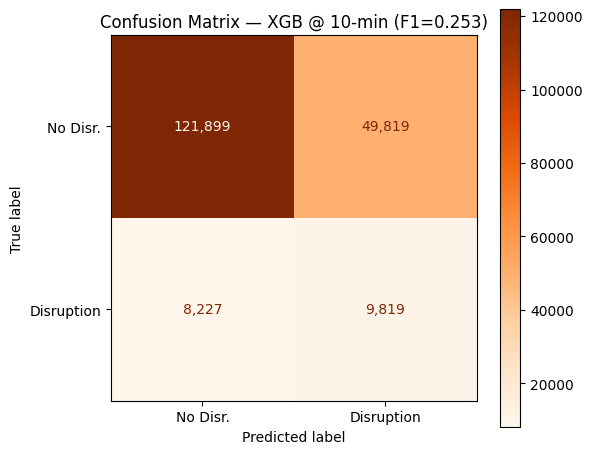

Saved: table + 3 individual figs


In [48]:
# Threshold comparison table + individual plots

r_5 = results_w['XGB + class weight']

threshold_comp = pd.DataFrame([
    {'Threshold': '>= 5 min',
     'Pos_Rate_Train': f'{y_train.mean()*100:.1f}%',
     'Pos_Rate_Test': f'{y_test.mean()*100:.1f}%',
     'Imbalance': f'{(y_train==0).sum()/(y_train==1).sum():.1f}:1',
     'PR-AUC': round(r_5['pr_auc'], 4),
     'Precision': round(r_5['precision'], 4),
     'Recall': round(r_5['recall'], 4),
     'F1': round(r_5['f1'], 4)},
    {'Threshold': '>= 10 min',
     'Pos_Rate_Train': f'{y_train_10.mean()*100:.1f}%',
     'Pos_Rate_Test': f'{y_test_10.mean()*100:.1f}%',
     'Imbalance': f'{(y_train_10==0).sum()/(y_train_10==1).sum():.1f}:1',
     'PR-AUC': round(r_10['pr_auc'], 4),
     'Precision': round(r_10['precision'], 4),
     'Recall': round(r_10['recall'], 4),
     'F1': round(r_10['f1'], 4)},
])


print('THRESHOLD COMPARISON — XGB + Class Weight (Test Set)')

display(threshold_comp)
threshold_comp.to_excel(f'{EXPORT_DIR}/table_threshold_comparison_5v10.xlsx', index=False)

# Individual PR curve comparison
fig, ax = plt.subplots(figsize=(10, 7))
p5, rc5, _ = precision_recall_curve(y_test, r_5['y_prob'])
p10, rc10, _ = precision_recall_curve(y_test_10, r_10['y_prob'])
ax.plot(rc5, p5, label=f'>= 5 min (AP={r_5["pr_auc"]:.3f})', linewidth=2)
ax.plot(rc10, p10, label=f'>= 10 min (AP={r_10["pr_auc"]:.3f})', linewidth=2)
ax.axhline(y_test.mean(), ls=':', color='blue', alpha=0.4, label=f'5-min base ({y_test.mean():.3f})')
ax.axhline(y_test_10.mean(), ls=':', color='orange', alpha=0.4, label=f'10-min base ({y_test_10.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves: 5-min vs 10-min Threshold'); ax.legend(fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_pr_5v10.png', dpi=150, bbox_inches='tight')
plt.show()

# Individual CM 5-min
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(r_5['cm'], display_labels=['No Disr.','Disruption']).plot(
    ax=ax, cmap='Blues', values_format=',')
ax.set_title(f'Confusion Matrix — XGB @ 5-min (F1={r_5["f1"]:.3f})')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_cm_5min.png', dpi=150, bbox_inches='tight')
plt.show()

# Individual CM 10-min
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(r_10['cm'], display_labels=['No Disr.','Disruption']).plot(
    ax=ax, cmap='Oranges', values_format=',')
ax.set_title(f'Confusion Matrix — XGB @ 10-min (F1={r_10["f1"]:.3f})')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_cm_10min.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: table + 3 individual figs')


## 9. PR Curves

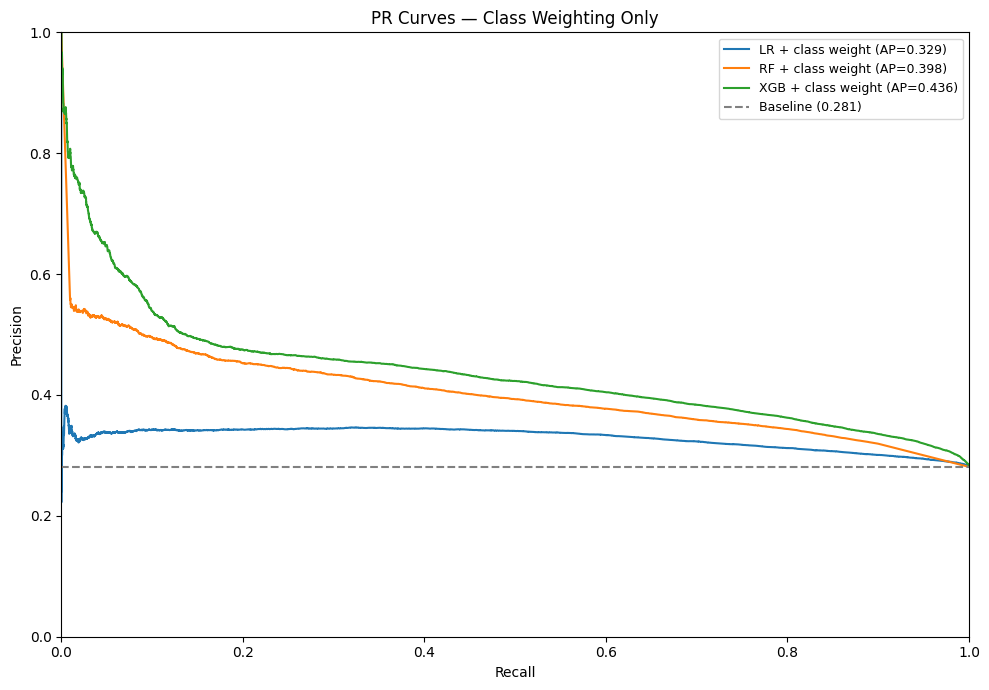

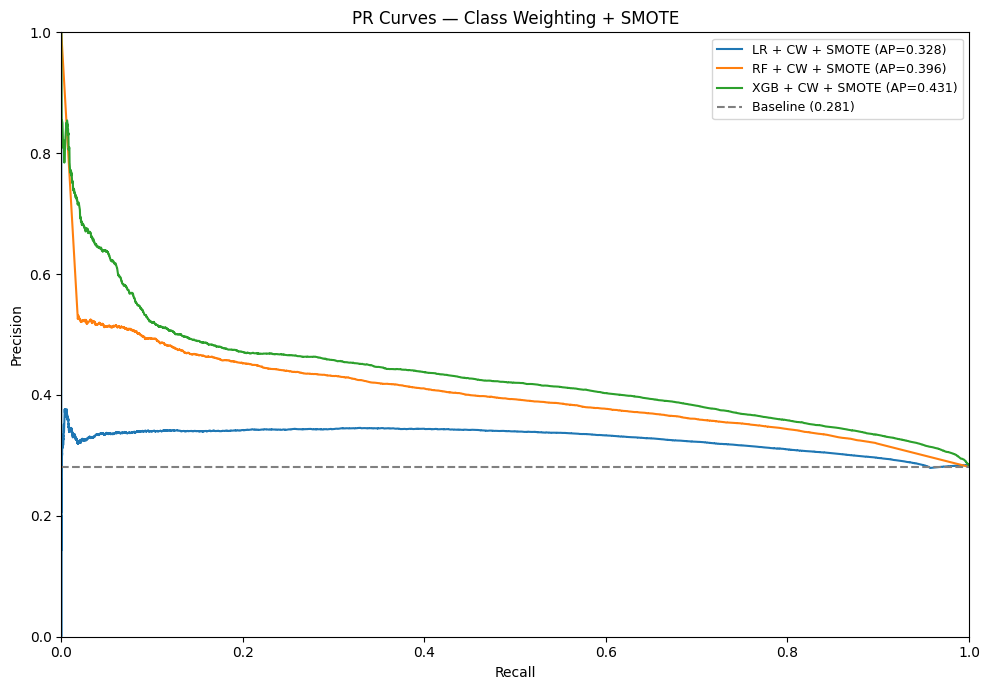

Saved: fig_pr_curves_cw.png + fig_pr_curves_smote.png


In [49]:
# PR curves — individual plots

# Plot 1: Class Weighting Only
fig, ax = plt.subplots(figsize=(10, 7))
for name, r in results_w.items():
    p, rc, _ = precision_recall_curve(y_test, r['y_prob'])
    ax.plot(rc, p, label=f'{name} (AP={r["pr_auc"]:.3f})')
ax.axhline(y_test.mean(), ls='--', color='grey', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — Class Weighting Only')
ax.legend(loc='upper right', fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_pr_curves_cw.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Class Weighting + SMOTE
fig, ax = plt.subplots(figsize=(10, 7))
for name, r in results_s.items():
    p, rc, _ = precision_recall_curve(y_test, r['y_prob'])
    ax.plot(rc, p, label=f'{name} (AP={r["pr_auc"]:.3f})')
ax.axhline(y_test.mean(), ls='--', color='grey', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — Class Weighting + SMOTE')
ax.legend(loc='upper right', fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_pr_curves_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_pr_curves_cw.png + fig_pr_curves_smote.png')


## 10. Confusion Matrices

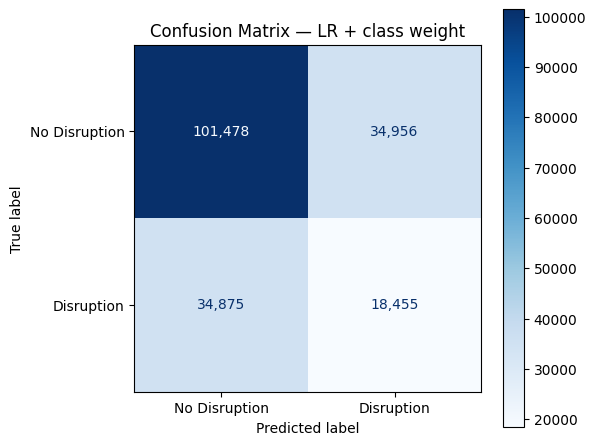

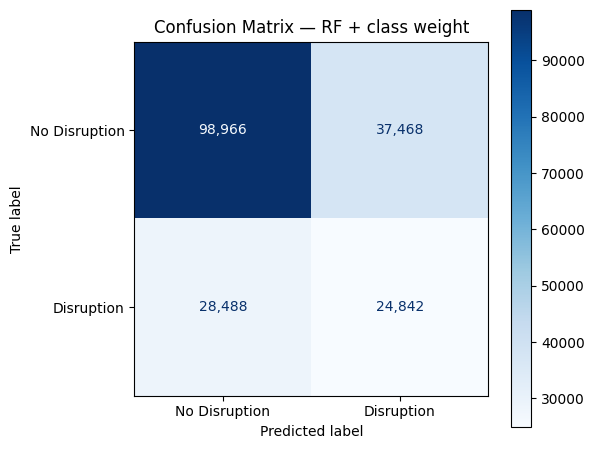

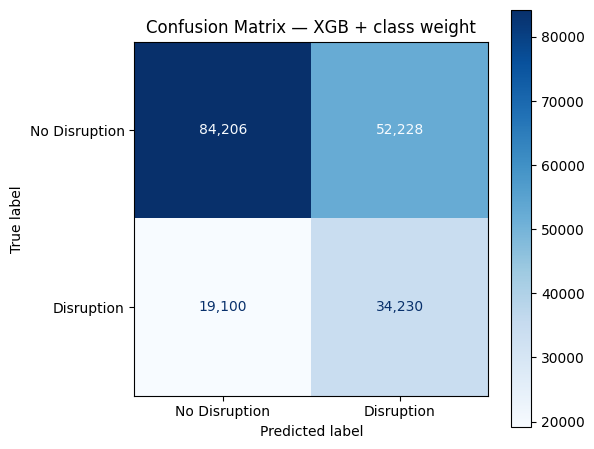

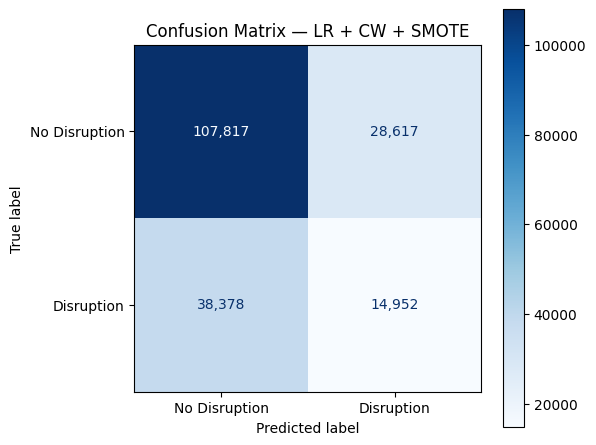

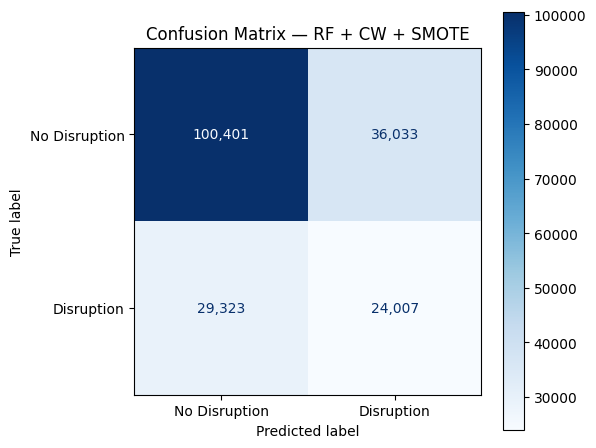

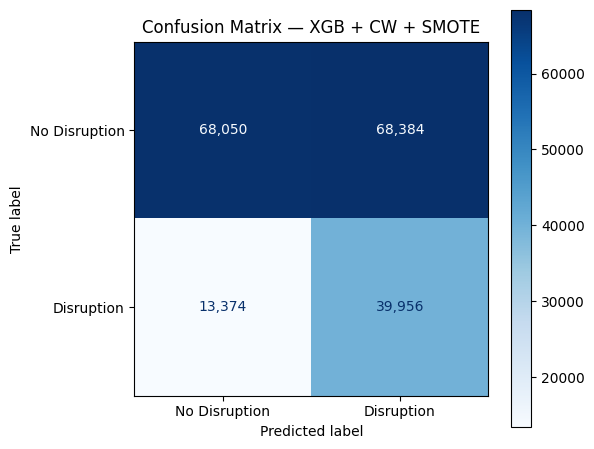

Saved: 6 individual confusion matrix figures


In [50]:
# Confusion matrices — individual plots
for name, r in all_r.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(r['cm'], display_labels=['No Disruption','Disruption']).plot(
        ax=ax, cmap='Blues', values_format=',')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('+', '').replace('(', '').replace(')', '')
    fig.savefig(f'{EXPORT_DIR}/fig_cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Saved: {len(all_r)} individual confusion matrix figures')


## 11. Threshold Analysis

Best model: XGB + class weight
Optimal threshold: 0.45 | Prec:0.3602 Rec:0.7673 F1:0.4903


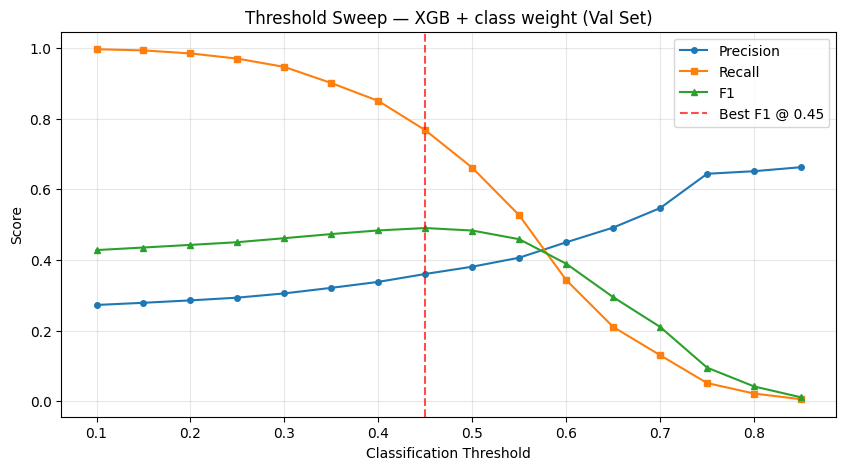

Saved: table + fig


,threshold,precision,recall,f1
0,0.10,0.272397,0.996677,0.427858
1,0.15,0.278568,0.993313,0.435112
2,0.20,0.285393,0.984794,0.442539
3,0.25,0.293105,0.970050,0.450185
4,0.30,0.305166,0.946526,0.461532
5,0.35,0.320883,0.900806,0.473203
6,0.40,0.337771,0.850232,0.483473
7,0.45,0.360190,0.767331,0.490252
8,0.50,0.380727,0.661108,0.483189
9,0.55,0.406286,0.526445,0.458626


In [51]:
# Threshold sweep on VALIDATION set
best_name = comp_df.iloc[0]['Model']
best_model = all_r[best_name]['model']
print(f'Best model: {best_name}')

yv_prob = best_model.predict_proba(X_val)[:,1]
sweep = []
for t in np.arange(0.1, 0.9, 0.05):
    yv_p = (yv_prob >= t).astype(int)
    sweep.append({'threshold':round(t,2),'precision':precision_score(y_val,yv_p,zero_division=0),
                  'recall':recall_score(y_val,yv_p,zero_division=0),'f1':f1_score(y_val,yv_p,zero_division=0)})
sweep_df = pd.DataFrame(sweep)
best_row = sweep_df.loc[sweep_df['f1'].idxmax()]
best_thresh = best_row['threshold']
print(f'Optimal threshold: {best_thresh} | Prec:{best_row["precision"]:.4f} Rec:{best_row["recall"]:.4f} F1:{best_row["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', marker='o', ms=4)
ax.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall', marker='s', ms=4)
ax.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', marker='^', ms=4)
ax.axvline(x=best_thresh, ls='--', color='red', alpha=0.7, label=f'Best F1 @ {best_thresh}')
ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Threshold Sweep — {best_name} (Val Set)'); ax.legend(); ax.grid(True, alpha=0.3)
sweep_df.to_excel(f'{EXPORT_DIR}/table_threshold_sweep.xlsx', index=False)
fig.savefig(f'{EXPORT_DIR}/fig_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: table + fig')
display(sweep_df)


In [52]:
# Apply optimal threshold to TEST set
yt_prob = best_model.predict_proba(X_test)[:,1]
yt_pred = (yt_prob >= best_thresh).astype(int)
print(f'Test Results (threshold={best_thresh}) ')
print(f'PR-AUC:  {average_precision_score(y_test,yt_prob):.4f}')
print(f'Prec:    {precision_score(y_test,yt_pred,zero_division=0):.4f}')
print(f'Recall:  {recall_score(y_test,yt_pred,zero_division=0):.4f}')
print(f'F1:      {f1_score(y_test,yt_pred,zero_division=0):.4f}')
print(classification_report(y_test, yt_pred, target_names=['No Disruption','Disruption'], digits=4))
print(confusion_matrix(y_test, yt_pred))

pd.DataFrame([{'Model':best_name,'Threshold':best_thresh,
    'PR-AUC':round(average_precision_score(y_test,yt_prob),4),
    'Precision':round(precision_score(y_test,yt_pred,zero_division=0),4),
    'Recall':round(recall_score(y_test,yt_pred,zero_division=0),4),
    'F1':round(f1_score(y_test,yt_pred,zero_division=0),4)}]).to_excel(f'{EXPORT_DIR}/table_tuned_threshold_results.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_tuned_threshold_results.xlsx')
# Display tuned results
tuned_df = pd.DataFrame([{'Model':best_name,'Threshold':best_thresh,
    'PR-AUC':round(average_precision_score(y_test,yt_prob),4),
    'Precision':round(precision_score(y_test,yt_pred,zero_division=0),4),
    'Recall':round(recall_score(y_test,yt_pred,zero_division=0),4),
    'F1':round(f1_score(y_test,yt_pred,zero_division=0),4)}])
display(tuned_df)


Test Results (threshold=0.45) 
PR-AUC:  0.4357
Prec:    0.3751
Recall:  0.7430
F1:      0.4985
               precision    recall  f1-score   support

No Disruption     0.8371    0.5161    0.6385    136434
   Disruption     0.3751    0.7430    0.4985     53330

     accuracy                         0.5799    189764
    macro avg     0.6061    0.6295    0.5685    189764
 weighted avg     0.7072    0.5799    0.5992    189764

[[70415 66019]
 [13707 39623]]
Saved: prototype2_outputs/table_tuned_threshold_results.xlsx


,Model,Threshold,PR-AUC,Precision,Recall,F1
0,XGB + class weight,0.45,0.4357,0.3751,0.743,0.4985


## 12. Probability Calibration

In [53]:
# Calibration
cal_sig = CalibratedClassifierCV(best_model, method='sigmoid', cv='prefit'); cal_sig.fit(X_val, y_val)
cal_iso = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit'); cal_iso.fit(X_val, y_val)

p_uncal = best_model.predict_proba(X_test)[:,1]
p_sig = cal_sig.predict_proba(X_test)[:,1]
p_iso = cal_iso.predict_proba(X_test)[:,1]

print('PR-AUC comparison:')
for lbl, p in [('Uncalibrated',p_uncal),('Platt',p_sig),('Isotonic',p_iso)]:
    print(f'  {lbl}: {average_precision_score(y_test,p):.4f}')

pd.DataFrame([{'Method':'Uncalibrated','PR-AUC':round(average_precision_score(y_test,p_uncal),4)},
    {'Method':'Platt','PR-AUC':round(average_precision_score(y_test,p_sig),4)},
    {'Method':'Isotonic','PR-AUC':round(average_precision_score(y_test,p_iso),4)}]).to_excel(f'{EXPORT_DIR}/table_calibration_comparison.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_calibration_comparison.xlsx')
cal_df = pd.DataFrame([{'Method':'Uncalibrated','PR-AUC':round(average_precision_score(y_test,p_uncal),4)},
    {'Method':'Platt','PR-AUC':round(average_precision_score(y_test,p_sig),4)},
    {'Method':'Isotonic','PR-AUC':round(average_precision_score(y_test,p_iso),4)}])
display(cal_df)


PR-AUC comparison:
  Uncalibrated: 0.4357
  Platt: 0.4357
  Isotonic: 0.4295
Saved: prototype2_outputs/table_calibration_comparison.xlsx


,Method,PR-AUC
0,Uncalibrated,0.4357
1,Platt,0.4357
2,Isotonic,0.4295


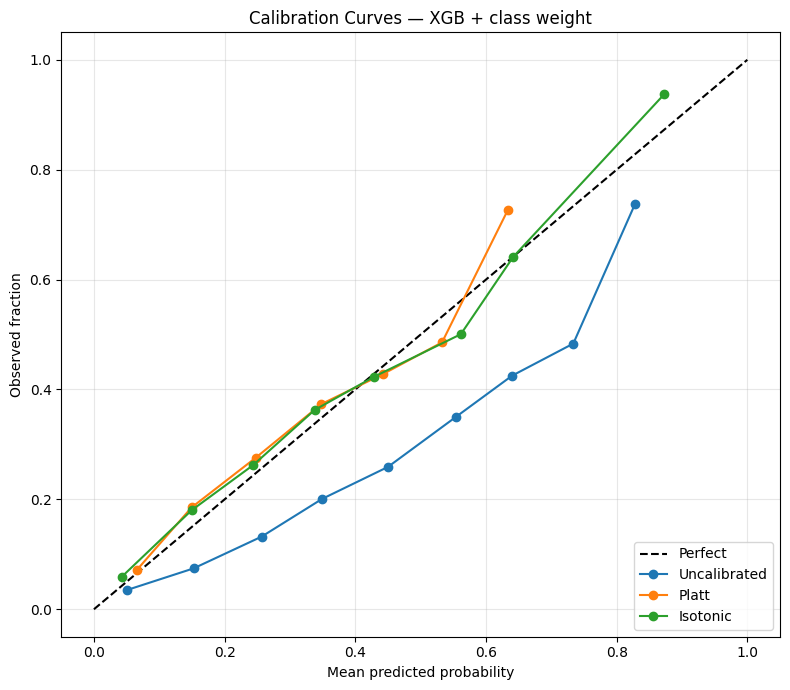

Saved: prototype2_outputs/fig_calibration_curves.png


In [54]:
# Calibration curves
fig, ax = plt.subplots(figsize=(8,7))
ax.plot([0,1],[0,1],'k--', label='Perfect')
for lbl, p in [('Uncalibrated',p_uncal),('Platt',p_sig),('Isotonic',p_iso)]:
    pt, pp = calibration_curve(y_test, p, n_bins=10, strategy='uniform')
    ax.plot(pp, pt, marker='o', label=lbl)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed fraction')
ax.set_title(f'Calibration Curves — {best_name}'); ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {EXPORT_DIR}/fig_calibration_curves.png')

## 13. Feature Importance

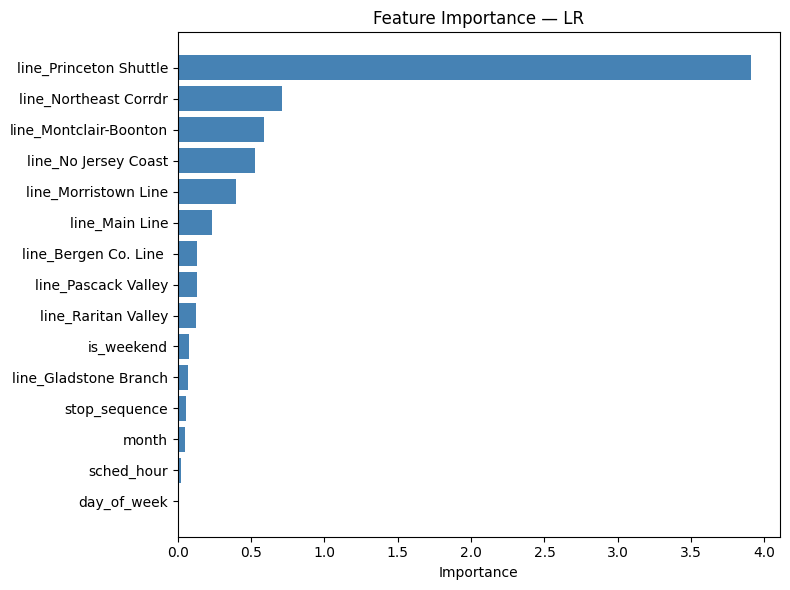

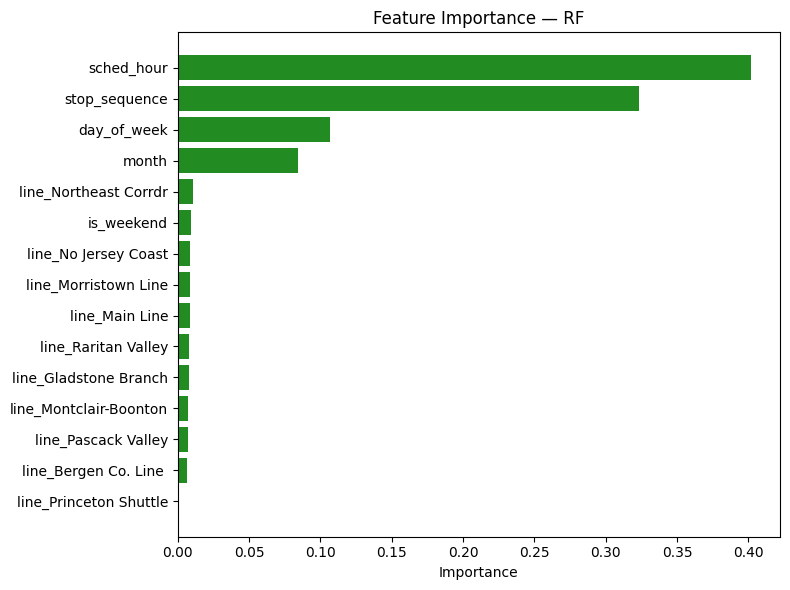

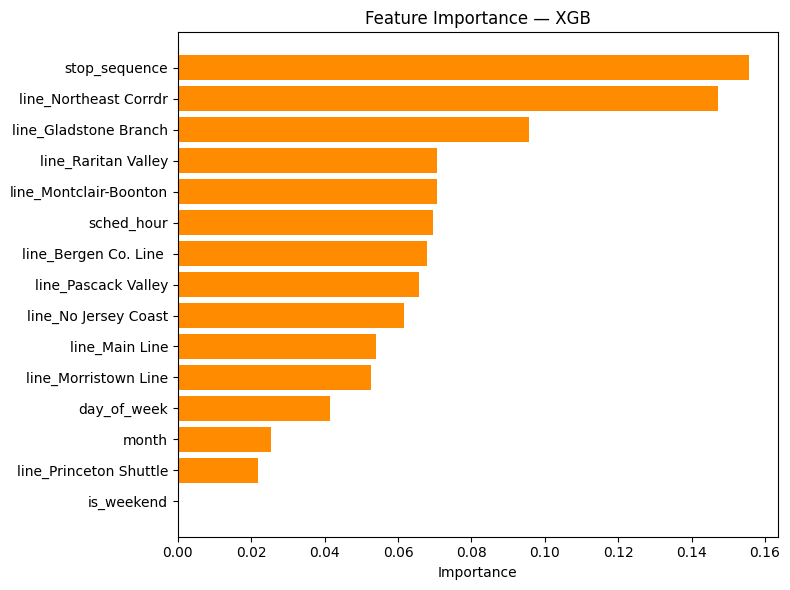


Top 10 features per model:

LR:


,Feature,Importance
0,line_Princeton Shuttle,3.910681
1,line_Northeast Corrdr,0.707385
2,line_Montclair-Boonton,0.588644
3,line_No Jersey Coast,0.525481
4,line_Morristown Line,0.398139
5,line_Main Line,0.233259
6,line_Bergen Co. Line,0.127854
7,line_Pascack Valley,0.127812
8,line_Raritan Valley,0.122730
9,is_weekend,0.078259



RF:


,Feature,Importance
0,sched_hour,0.402089
1,stop_sequence,0.323450
2,day_of_week,0.106606
3,month,0.084421
4,line_Northeast Corrdr,0.010432
5,is_weekend,0.009367
6,line_No Jersey Coast,0.008724
7,line_Morristown Line,0.008553
8,line_Main Line,0.008464
9,line_Raritan Valley,0.008028



XGB:


,Feature,Importance
0,stop_sequence,0.155709
1,line_Northeast Corrdr,0.147310
2,line_Gladstone Branch,0.095812
3,line_Raritan Valley,0.070727
4,line_Montclair-Boonton,0.070568
5,sched_hour,0.069495
6,line_Bergen Co. Line,0.067829
7,line_Pascack Valley,0.065662
8,line_No Jersey Coast,0.061566
9,line_Main Line,0.053902


Saved: 3 individual feature importance figs + 3 xlsx


In [55]:
# Feature importance — individual plots
fnames = X_train.columns.tolist()

lr_imp = np.abs(results_w['LR + class weight']['model'].coef_[0])
rf_imp = results_w['RF + class weight']['model'].feature_importances_
xgb_imp = results_w['XGB + class weight']['model'].feature_importances_

for label, imp, color in [('LR', lr_imp, 'steelblue'),
                           ('RF', rf_imp, 'forestgreen'),
                           ('XGB', xgb_imp, 'darkorange')]:
    fig, ax = plt.subplots(figsize=(8, 6))
    idx = np.argsort(imp)[::-1][:15]
    ax.barh([fnames[i] for i in idx], imp[idx], color=color)
    ax.set_xlabel('Importance'); ax.set_title(f'Feature Importance — {label}')
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(f'{EXPORT_DIR}/fig_feature_importance_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

for lbl, imp in [('lr',lr_imp),('rf',rf_imp),('xgb',xgb_imp)]:
    pd.DataFrame({'Feature':fnames,'Importance':imp}).sort_values('Importance',ascending=False).to_excel(
        f'{EXPORT_DIR}/table_feature_importance_{lbl}.xlsx', index=False)

print('\nTop 10 features per model:')
for lbl, imp in [('LR',lr_imp),('RF',rf_imp),('XGB',xgb_imp)]:
    print(f'\n{lbl}:')
    display(pd.DataFrame({'Feature':fnames,'Importance':imp}).sort_values('Importance',ascending=False).head(10).reset_index(drop=True))
print(f'Saved: 3 individual feature importance figs + 3 xlsx')


## 14. Ranked Segment Risk Output

In [56]:
# Ranked segment risk
test_df = df_sorted.iloc[val_end:].copy()
test_df['risk_score'] = cal_iso.predict_proba(X_test)[:,1]

seg_risk = test_df.groupby('segment_id').agg(
    mean_risk=('risk_score','mean'), records=('risk_score','count'),
    actual_rate=('disruption','mean'), disruptions=('disruption','sum')
).reset_index()

seg_names = test_df.groupby('segment_id').agg(from_st=('from','first'), to_st=('to','first'), line=('line','first')).reset_index()
seg_risk = seg_risk.merge(seg_names, on='segment_id').sort_values('mean_risk', ascending=False).reset_index(drop=True)

dcols = ['segment_id','from_st','to_st','line','mean_risk','actual_rate','disruptions','records']
print('TOP 20 SEGMENTS BY PREDICTED DISRUPTION RISK')
print(seg_risk[dcols].head(20).to_string(index=False))
seg_risk[dcols].to_excel(f'{EXPORT_DIR}/table_ranked_segment_risk.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_ranked_segment_risk.xlsx')
display(seg_risk[dcols].head(20))


TOP 20 SEGMENTS BY PREDICTED DISRUPTION RISK
    segment_id             from_st             to_st              line  mean_risk  actual_rate  disruptions  records
  152.0->150.0       Walnut Street   Upper Montclair Montclair-Boonton   0.625000     0.900000            9       10
    96.0->34.0      Mountain Lakes          Denville Montclair-Boonton   0.509655     0.370370           60      162
    20.0->96.0             Boonton    Mountain Lakes Montclair-Boonton   0.481386     0.450617           73      162
   69.0->147.0        Lincoln Park            Towaco Montclair-Boonton   0.471570     0.462963           75      162
    98.0->69.0       Mountain View      Lincoln Park Montclair-Boonton   0.469111     0.500000           81      162
 39635.0->98.0      Wayne-Route 23     Mountain View Montclair-Boonton   0.466288     0.592593           96      162
   147.0->20.0              Towaco           Boonton Montclair-Boonton   0.463541     0.419753           68      162
 72.0->39635.0     

,segment_id,from_st,to_st,line,mean_risk,actual_rate,disruptions,records
0,152.0->150.0,Walnut Street,Upper Montclair,Montclair-Boonton,0.625000,0.900000,9,10
1,96.0->34.0,Mountain Lakes,Denville,Montclair-Boonton,0.509655,0.370370,60,162
2,20.0->96.0,Boonton,Mountain Lakes,Montclair-Boonton,0.481386,0.450617,73,162
3,69.0->147.0,Lincoln Park,Towaco,Montclair-Boonton,0.471570,0.462963,75,162
4,98.0->69.0,Mountain View,Lincoln Park,Montclair-Boonton,0.469111,0.500000,81,162
5,39635.0->98.0,Wayne-Route 23,Mountain View,Montclair-Boonton,0.466288,0.592593,96,162
6,147.0->20.0,Towaco,Boonton,Montclair-Boonton,0.463541,0.419753,68,162
7,72.0->39635.0,Little Falls,Wayne-Route 23,Montclair-Boonton,0.455508,0.500000,81,162
8,38081.0->72.0,Montclair State U,Little Falls,Montclair-Boonton,0.441433,0.444444,72,162
9,39472.0->67.0,Mount Arlington,Lake Hopatcong,Montclair-Boonton,0.436478,0.412037,89,216


## 14b. Segment-Level Early Warning Output

In [57]:
# Segment-Level Early Warning System Output

# A segment-level early warning table that classifies each segment
# into risk tiers based on calibrated disruption probabilities.

# Define risk tiers based on predicted disruption probability
def assign_risk_tier(risk_score):
    if risk_score >= 0.5:
        return 'HIGH'
    elif risk_score >= 0.35:
        return 'MEDIUM'
    elif risk_score >= 0.2:
        return 'LOW'
    else:
        return 'MINIMAL'

# Build the early warning table from segment-level risk scores
seg_warning = seg_risk.copy()
seg_warning['risk_tier'] = seg_warning['mean_risk'].apply(assign_risk_tier)
seg_warning['risk_score_pct'] = (seg_warning['mean_risk'] * 100).round(1)

# Add explanation cues — why is this segment flagged?
# Top contributing factor for each segment based on its line and disruption history
seg_warning['explanation'] = seg_warning.apply(
    lambda row: f"Line: {row['line']} | Actual disruption rate: {row['actual_rate']*100:.1f}% | "
                f"Based on {row['records']} observations",
    axis=1
)

# Display the early warning output
warning_cols = ['segment_id', 'from_st', 'to_st', 'line', 'risk_tier', 'risk_score_pct',
                'actual_rate', 'disruptions', 'records', 'explanation']

print('SEGMENT-LEVEL EARLY WARNING SYSTEM — PREDICTED DISRUPTION RISK')
print('Prediction based on imbalance-aware machine learning (calibrated probabilities)')

# Show risk tier summary
tier_summary = seg_warning['risk_tier'].value_counts().reindex(['HIGH','MEDIUM','LOW','MINIMAL']).fillna(0).astype(int)
print(f'\nRisk Tier Summary:')
print(f'  HIGH risk segments:    {tier_summary.get("HIGH", 0):>4} segments — immediate attention recommended')
print(f'  MEDIUM risk segments:  {tier_summary.get("MEDIUM", 0):>4} segments — monitor closely')
print(f'  LOW risk segments:     {tier_summary.get("LOW", 0):>4} segments — routine monitoring')
print(f'  MINIMAL risk segments: {tier_summary.get("MINIMAL", 0):>4} segments — no action needed')

# Display HIGH risk segments
high_risk = seg_warning[seg_warning['risk_tier'] == 'HIGH'][warning_cols]

print(f'HIGH RISK SEGMENTS ({len(high_risk)} segments)')

if len(high_risk) > 0:
    display(high_risk.head(20))
else:
    print('No segments currently at HIGH risk.')

# Display MEDIUM risk segments
medium_risk = seg_warning[seg_warning['risk_tier'] == 'MEDIUM'][warning_cols]

print(f'MEDIUM RISK SEGMENTS ({len(medium_risk)} segments)')

if len(medium_risk) > 0:
    display(medium_risk.head(20))
else:
    print('No segments currently at MEDIUM risk.')

# Export the full early warning table
seg_warning[warning_cols].to_excel(f'{EXPORT_DIR}/table_early_warning_output.xlsx', index=False)

# Export tier summary
tier_df = pd.DataFrame({'Risk_Tier': tier_summary.index, 'Segment_Count': tier_summary.values})
tier_df.to_excel(f'{EXPORT_DIR}/table_risk_tier_summary.xlsx', index=False)
display(tier_df)

print(f'\nSaved: {EXPORT_DIR}/table_early_warning_output.xlsx')
print(f'Saved: {EXPORT_DIR}/table_risk_tier_summary.xlsx')


SEGMENT-LEVEL EARLY WARNING SYSTEM — PREDICTED DISRUPTION RISK
Prediction based on imbalance-aware machine learning (calibrated probabilities)

Risk Tier Summary:
  HIGH risk segments:       2 segments — immediate attention recommended
  MEDIUM risk segments:    80 segments — monitor closely
  LOW risk segments:      334 segments — routine monitoring
  MINIMAL risk segments:  125 segments — no action needed
HIGH RISK SEGMENTS (2 segments)


,segment_id,from_st,to_st,line,risk_tier,risk_score_pct,actual_rate,disruptions,records,explanation
0,152.0->150.0,Walnut Street,Upper Montclair,Montclair-Boonton,HIGH,62.5,0.90000,9,10,Line: Montclair-Boonton | Actual disruption ra...
1,96.0->34.0,Mountain Lakes,Denville,Montclair-Boonton,HIGH,51.0,0.37037,60,162,Line: Montclair-Boonton | Actual disruption ra...


MEDIUM RISK SEGMENTS (80 segments)


,segment_id,from_st,to_st,line,risk_tier,risk_score_pct,actual_rate,disruptions,records,explanation
2,20.0->96.0,Boonton,Mountain Lakes,Montclair-Boonton,MEDIUM,48.1,0.450617,73,162,Line: Montclair-Boonton | Actual disruption ra...
3,69.0->147.0,Lincoln Park,Towaco,Montclair-Boonton,MEDIUM,47.2,0.462963,75,162,Line: Montclair-Boonton | Actual disruption ra...
4,98.0->69.0,Mountain View,Lincoln Park,Montclair-Boonton,MEDIUM,46.9,0.500000,81,162,Line: Montclair-Boonton | Actual disruption ra...
5,39635.0->98.0,Wayne-Route 23,Mountain View,Montclair-Boonton,MEDIUM,46.6,0.592593,96,162,Line: Montclair-Boonton | Actual disruption ra...
6,147.0->20.0,Towaco,Boonton,Montclair-Boonton,MEDIUM,46.4,0.419753,68,162,Line: Montclair-Boonton | Actual disruption ra...
7,72.0->39635.0,Little Falls,Wayne-Route 23,Montclair-Boonton,MEDIUM,45.6,0.500000,81,162,Line: Montclair-Boonton | Actual disruption ra...
8,38081.0->72.0,Montclair State U,Little Falls,Montclair-Boonton,MEDIUM,44.1,0.444444,72,162,Line: Montclair-Boonton | Actual disruption ra...
9,39472.0->67.0,Mount Arlington,Lake Hopatcong,Montclair-Boonton,MEDIUM,43.6,0.412037,89,216,Line: Montclair-Boonton | Actual disruption ra...
10,35.0->39472.0,Dover,Mount Arlington,Montclair-Boonton,MEDIUM,43.4,0.467593,101,216,Line: Montclair-Boonton | Actual disruption ra...
11,76.0->12.0,Lyons,Basking Ridge,Gladstone Branch,MEDIUM,43.2,0.521622,193,370,Line: Gladstone Branch | Actual disruption rat...


,Risk_Tier,Segment_Count
0,HIGH,2
1,MEDIUM,80
2,LOW,334
3,MINIMAL,125



Saved: prototype2_outputs/table_early_warning_output.xlsx
Saved: prototype2_outputs/table_risk_tier_summary.xlsx


## 14c. Segment Risk Distribution Visualisation

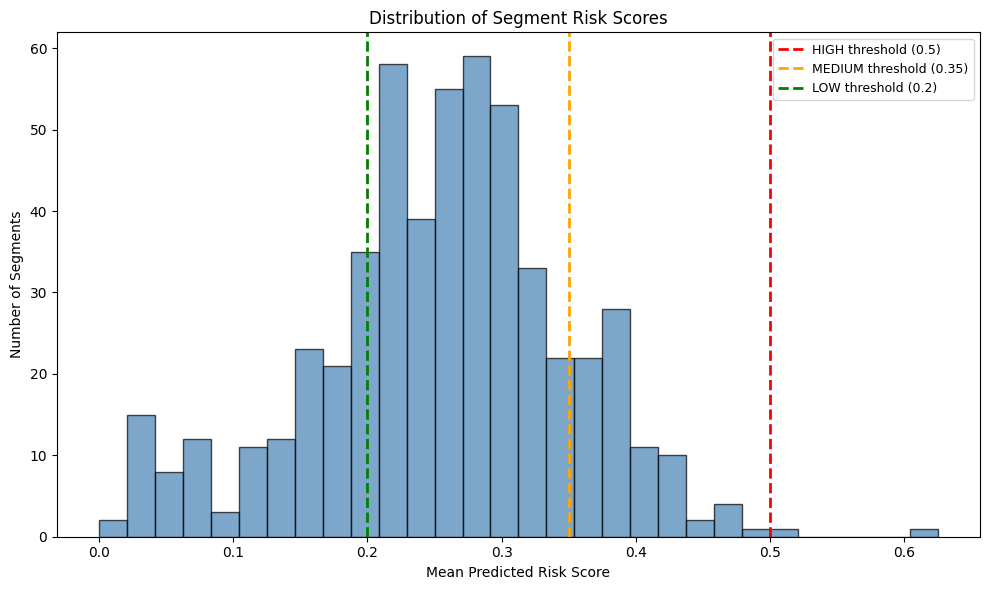

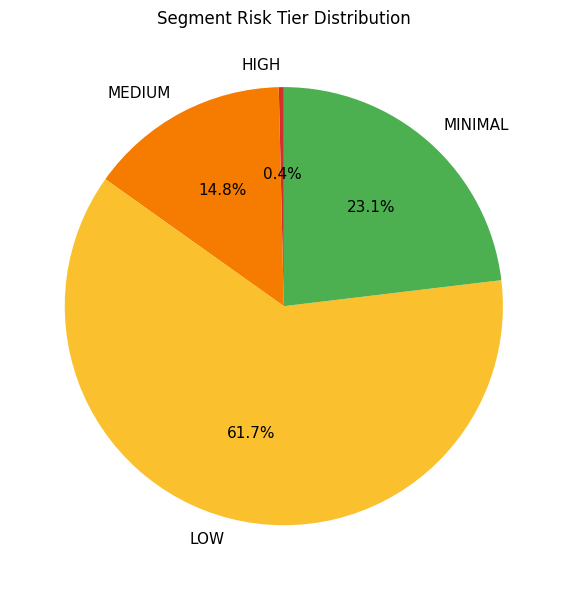

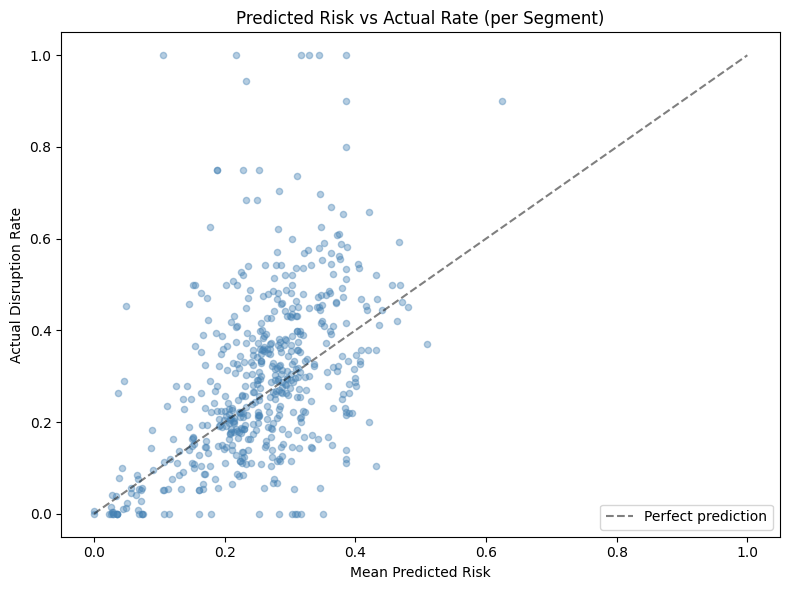

Saved: 3 individual segment risk figs


In [58]:
# Segment risk visualisation — individual plots

# Plot 1: Risk score distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(seg_warning['mean_risk'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='HIGH threshold (0.5)')
ax.axvline(x=0.35, color='orange', linestyle='--', linewidth=2, label='MEDIUM threshold (0.35)')
ax.axvline(x=0.2, color='green', linestyle='--', linewidth=2, label='LOW threshold (0.2)')
ax.set_xlabel('Mean Predicted Risk Score'); ax.set_ylabel('Number of Segments')
ax.set_title('Distribution of Segment Risk Scores'); ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Risk tier pie chart
fig, ax = plt.subplots(figsize=(8, 6))
tier_counts = seg_warning['risk_tier'].value_counts().reindex(['HIGH','MEDIUM','LOW','MINIMAL']).fillna(0)
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#4caf50']
ax.pie(tier_counts.values, labels=tier_counts.index, colors=colors,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Segment Risk Tier Distribution')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_risk_tier_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(seg_warning['mean_risk'], seg_warning['actual_rate'], alpha=0.4, s=20, color='steelblue')
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Mean Predicted Risk'); ax.set_ylabel('Actual Disruption Rate')
ax.set_title('Predicted Risk vs Actual Rate (per Segment)'); ax.legend()
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 3 individual segment risk figs')


## 15. Classification Reports

In [59]:
# Classification reports
with open(f'{EXPORT_DIR}/classification_reports.txt', 'w') as f:
    for name, r in all_r.items():
        hdr = f"{'='*60}\n{name}\n{'='*60}"
        rpt = classification_report(y_test, r['y_pred'], target_names=['No Disruption','Disruption'], digits=4)
        print(hdr); print(rpt)
        f.write(hdr+'\n'+rpt+'\n')
print(f'Saved: {EXPORT_DIR}/classification_reports.txt')

LR + class weight
               precision    recall  f1-score   support

No Disruption     0.7442    0.7438    0.7440    136434
   Disruption     0.3455    0.3461    0.3458     53330

     accuracy                         0.6320    189764
    macro avg     0.5449    0.5449    0.5449    189764
 weighted avg     0.6322    0.6320    0.6321    189764

RF + class weight
               precision    recall  f1-score   support

No Disruption     0.7765    0.7254    0.7501    136434
   Disruption     0.3987    0.4658    0.4296     53330

     accuracy                         0.6524    189764
    macro avg     0.5876    0.5956    0.5899    189764
 weighted avg     0.6703    0.6524    0.6600    189764

XGB + class weight
               precision    recall  f1-score   support

No Disruption     0.8151    0.6172    0.7025    136434
   Disruption     0.3959    0.6419    0.4897     53330

     accuracy                         0.6241    189764
    macro avg     0.6055    0.6295    0.5961    189764
 w

## 16. Correlation Matrix

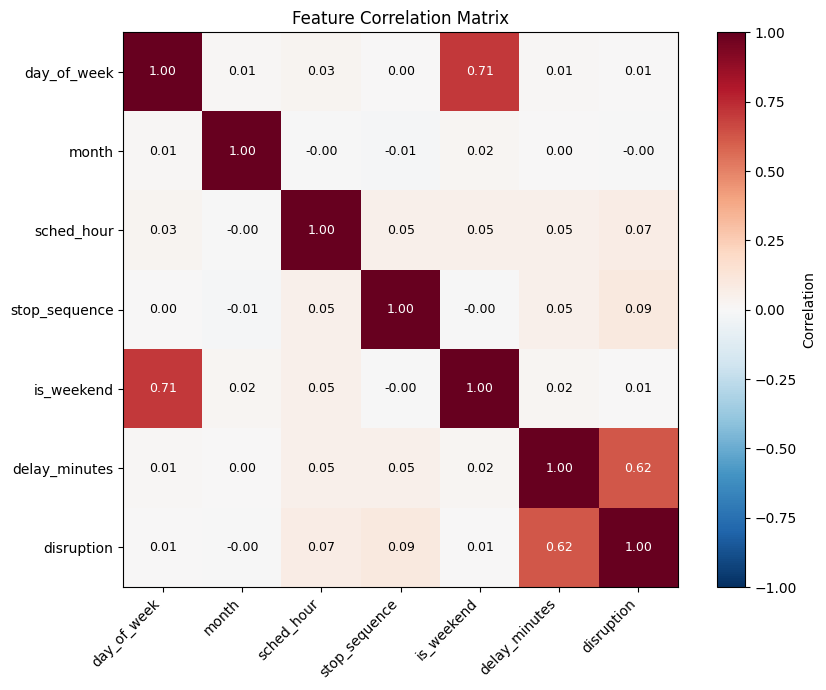

Saved: fig + csv


,day_of_week,month,sched_hour,stop_sequence,is_weekend,delay_minutes,disruption
day_of_week,1.000,0.012,0.026,0.000,0.710,0.013,0.007
month,0.012,1.000,-0.003,-0.010,0.021,0.004,-0.004
sched_hour,0.026,-0.003,1.000,0.052,0.050,0.053,0.072
stop_sequence,0.000,-0.010,0.052,1.000,-0.000,0.050,0.095
is_weekend,0.710,0.021,0.050,-0.000,1.000,0.018,0.007
delay_minutes,0.013,0.004,0.053,0.050,0.018,1.000,0.623
disruption,0.007,-0.004,0.072,0.095,0.007,0.623,1.000


In [60]:
# Correlation matrix
cc = ['day_of_week','month','sched_hour','stop_sequence','is_weekend']
cm = df[cc + ['delay_minutes','disruption']].corr()
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(cm, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j,i,f'{cm.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(cm.iloc[i,j])>0.5 else 'black')
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
cm.to_excel(f'{EXPORT_DIR}/table_correlation_matrix.xlsx')
plt.show()
print(f'Saved: fig + csv')
display(cm.round(3))


## 17. Summary

In [61]:
# Summary
print('PROTOTYPE 2 SUMMARY')
print(f'Dataset:       2019 Jan-Jun (6 months)')
print(f'Records:       {len(df):,}')
print(f'Segments:      {df["segment_id"].nunique()}')
print(f'Date range:    {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Threshold:     >= {THRESHOLD_MIN} min')
print(f'Pos rate:      {df["disruption"].mean():.4f} ({df["disruption"].mean()*100:.1f}%)')
print(f'Split:         70/15/15 time-ordered')
print(f'Models:        6 configs (3 models x 2 imbalance strategies)')
print(f'Best model:    {best_name}')
print(f'Best PR-AUC:   {comp_df.iloc[0]["PR-AUC"]}')
print(f'Best F1:       {comp_df.iloc[0]["F1"]}')
print(f'Opt threshold: {best_thresh}')
print(f'')
print('Exported files:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    sz = os.path.getsize(os.path.join(EXPORT_DIR, fn))
    print(f'  {fn:<45} {sz/1024:.1f} KB')

PROTOTYPE 2 SUMMARY
Dataset:       2019 Jan-Jun (6 months)
Records:       1,265,092
Segments:      561
Date range:    2019-01-01 to 2019-06-30
Threshold:     >= 5 min
Pos rate:      0.2635 (26.3%)
Split:         70/15/15 time-ordered
Models:        6 configs (3 models x 2 imbalance strategies)
Best model:    XGB + class weight
Best PR-AUC:   0.4357
Best F1:       0.4897
Opt threshold: 0.45

Exported files:
  classification_reports.txt                    2.8 KB
  fig_calibration_curves.png                    102.3 KB
  fig_cm_10min.png                              46.3 KB
  fig_cm_5min.png                               48.3 KB
  fig_cm_LR__CW__SMOTE.png                      43.2 KB
  fig_cm_LR__class_weight.png                   51.1 KB
  fig_cm_RF__CW__SMOTE.png                      49.3 KB
  fig_cm_RF__class_weight.png                   48.6 KB
  fig_cm_XGB__CW__SMOTE.png                     44.3 KB
  fig_cm_XGB__class_weight.png                  48.9 KB
  fig_correlation_matrix.png  